### An example of JASMINE Frame

The JASMINE satellite orbits around the Earth in the low-Earth orbit. The altitude of the satellite will be about 600 km. The satellite's velocity with respect to the Solar system barycenter will change in a timescale of about 100 min. Thus, the relativistic aberration effect will vary in the same timescale.

`jasmine_toolkit` provides a class `jasmine_frame` to calculate approximated positions and velocities of the satellite.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

matplotlib.rcParams['legend.frameon'] = False

In [2]:
from astropy.coordinates import SkyCoord
from astropy.time import Time

import astropy.units as u
import numpy as np
import warnings

Here, we import `jasmine_frame`, which contains another variant of [coordinate frames][1] used in `astropy.coordinates`, `JASMINEFrame`. `JASMINEFrame` is a subclass of `BaseRADecFrame`, where apparent coordinates are calculated when observed from the JASMINE satellite.

[1]: https://docs.astropy.org/en/stable/coordinates/index.html

In [3]:
from jasmine_toolkit.satellite import jasmine_frame
warnings.filterwarnings('ignore')

We describe how to use `jasmine_frame`. First, we determine observation epochs. Obtain the nominal orbital period from the instance. The origin of the epoch is set `2032-01-01` in the Barycentric Coordinate Time scale. The epoch ranges 180 days, divided by 1/8 days.

In [4]:
P = jasmine_frame.JASMINEFrame().orbital_period
P.to('min')

<Quantity 96.68643251 min>

In [5]:
t0 = Time('2032-01-01', scale='tcb') \
    + np.arange(0, 180, P.to_value('day') / 8) * u.day
t0

<Time object: scale='tcb' format='iso' value=['2032-01-01 00:00:00.000' '2032-01-01 00:12:05.148'
 '2032-01-01 00:24:10.296' ... '2032-06-28 23:27:58.941'
 '2032-06-28 23:40:04.089' '2032-06-28 23:52:09.237']>

The observation epochs are specified by `obstime`. The satellite orbital phases are set to zeros when not specified. 

In [6]:
jasmine_frame.JASMINEFrame(obstime=t0)

<JASMINEFrame Frame (obstime=['2032-01-01 00:00:00.000' '2032-01-01 00:12:05.148'
 '2032-01-01 00:24:10.296' ... '2032-06-28 23:27:58.941'
 '2032-06-28 23:40:04.089' '2032-06-28 23:52:09.237'], phase=0.0, altitude=600.0 km)>

The function `with_updated_phase()` returns a new frame with updated orbital phase.

In [7]:
jasmine = jasmine_frame.JASMINEFrame(obstime=t0).with_updated_phase()
jasmine

<JASMINEFrame Frame (obstime=['2032-01-01 00:00:00.000' '2032-01-01 00:12:05.148'
 '2032-01-01 00:24:10.296' ... '2032-06-28 23:27:58.941'
 '2032-06-28 23:40:04.089' '2032-06-28 23:52:09.237'], phase=[0.000000e+00 1.250000e-01 2.500000e-01 ... 2.680500e+03 2.680625e+03
 2.680750e+03], altitude=600.0 km)>

The orbit of the satellite is simplified, where JASMINE orbits in a circular orbit with a constant velocity. The orbital plane is perpendicular to the Earth-Sun direction. The basic information is listed below.

In [8]:
print(f'number of epochs: {len(jasmine)}')
print(f'orbital period: {jasmine.orbital_period.to("min"):.2f}')
print(f'orbital radius: {jasmine.orbital_radius.to("km"):.2f}')
print(f'orbital velocity: {jasmine.orbital_velocity.to("km/s"):.2f}')

number of epochs: 21447
orbital period: 96.69 min
orbital radius: 6978.10 km
orbital velocity: 7.56 km / s


Here, we illustrate the satellite position in the Barycentric Mean Ecliptic frame. `JASMIENFrame` has an attribute `obsbaryloc`, which returns the positions of the satellite at the observation epochs in the ICRS frame. Then, the satellite positions are converted into the Cartesian coordinate of the Barycentric Mean Ecliptic frame.

In [9]:
from astropy.coordinates import BarycentricMeanEcliptic as Ecliptic

sat = SkyCoord(jasmine.obsbaryloc).transform_to(Ecliptic())
pos = sat.cartesian.xyz.to('au').T

`JASMINEFrame` has a method to check a target observability, where the solar-observer-target angle and the Earth avoidance angle are considered. In the cell below, we evaluate the observabilities of the Galactic center region at the observation epochs.

In [10]:
galcen = SkyCoord(0.0 * u.deg, 0.0 * u.deg, frame='galactic').icrs
x = jasmine.observable(galcen)

We illustrate the satellite locations in the Barycentric Mean Ecliptic coordinate. The Ecliptic-$z$ axis is scaled for better visibility. The location of the Sun is indicated by the orange circle. The satellite positions are shown by the dots, which are shown in blue when the Galactic center is observable from JASMINE.

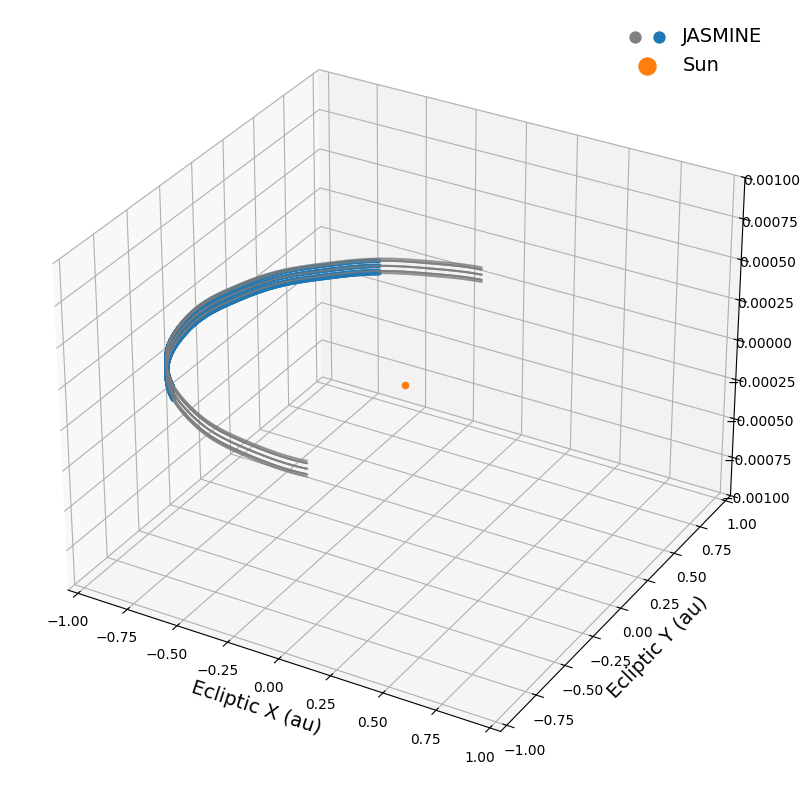

In [11]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(0, 0, 0, marker='o', color='C1', label='Sun')
ax.scatter(
  pos[x, 0], pos[x, 1], pos[x, 2],
   rasterized=True, marker='.', color='C0', label='JASMINE')
ax.scatter(
  pos[~x, 0], pos[~x, 1], pos[~x, 2],
  rasterized=True, s=1, marker='.', color='gray', alpha=0.2)

ax.set_xlabel('Ecliptic X (au)', fontsize=14)
ax.set_ylabel('Ecliptic Y (au)', fontsize=14)
ax.set_zlim([-1e-3, 1e-3])
ax.set_xlim([-1.05, 1.05])
ax.set_ylim([-1.05, 1.05])
ax.set_aspect('equalxy')

hg = ax.scatter([], [], s=250, marker='.', color='gray')
hb = ax.scatter([], [], s=250, marker='.', color='C0')
hs = ax.scatter([], [], s=150, marker='o', color='C1')

ax.legend(
  [(hg, hb), hs], ['JASMINE', 'Sun'], fontsize=14,
  handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)})

fig.tight_layout()
plt.show()

The satellite barycentric velocities at the first 2000 epochs are illustrated below. The thick lines show the Earth's velocities with respect to the Solar system barycenter.

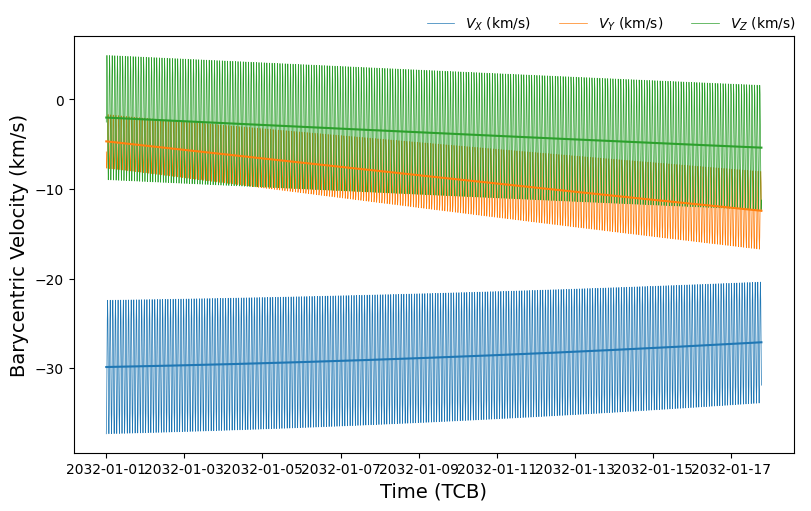

In [12]:
fig, ax = plt.subplots(
  figsize=(8, 5), layout='constrained')

N = 2000
vel_bary = jasmine[:N].obsbaryvel.xyz.to('km/s')
vel_geo = jasmine[:N].obsgeovel.xyz.to('km/s')

vel_earth = vel_bary - vel_geo

ax.plot(
  jasmine.obstime.datetime[:N], vel_bary[0], lw=0.5,
  label='$V_X$ (km/s)')
ax.plot(
  jasmine.obstime.datetime[:N], vel_bary[1], lw=0.5,
  label='$V_Y$ (km/s)')
ax.plot(
  jasmine.obstime.datetime[:N], vel_bary[2], lw=0.5,
  label='$V_Z$ (km/s)')

ax.plot(
  jasmine.obstime.datetime[:N], vel_earth[0],
  color='C0', lw=1.5)
ax.plot(
  jasmine.obstime.datetime[:N], vel_earth[1],
  color='C1', lw=1.5)
ax.plot(
  jasmine.obstime.datetime[:N], vel_earth[2],
  color='C2', lw=1.5)
ax.legend(
  loc='lower right', bbox_to_anchor=(1.02, 0.98), ncol=3)

ax.set_xlabel('Time (TCB)', fontsize=14)
ax.set_ylabel('Barycentric Velocity (km/s)', fontsize=14)

plt.show()

`JASMINEFrame` can provide apparent coordinate of objects when they are observed by JASMINE. The target positions are transformed into `JASMINEFrame`, which returns a `SkyCoord` instance that contains the apparent coordinates in the ICRS frame.

In [13]:
galcen_j = galcen.transform_to(jasmine)

The figure below illustrates the apparent positions of the Galactic center region. The red cross indicates the ICRS coordinates of the Galactic center. When the target is not observable, the lines are grayed out. The lines in different colors indicate the apparent coordinates in different orbital phases. The apparent position systematically moves in the RA direction, which is a combination of the aberration and parallax. The systematic offsets between the different colors indicate the contribution from the satellite orbital motion around the Earth.

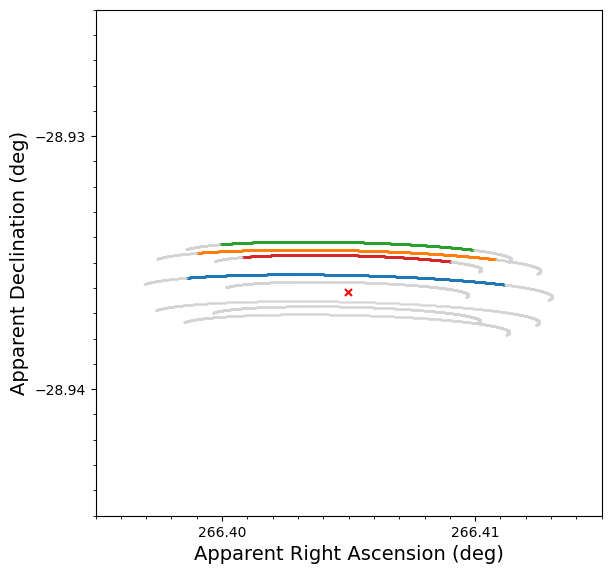

In [14]:
fig, ax = plt.subplots(figsize=(6, 6), layout='constrained')


ax.scatter(
  galcen.ra, galcen.dec, marker='x', s=25, color='red')

for n in range(8):
  y = x[n::8]
  ax.scatter(
    galcen_j.ra[n::8][y], galcen_j.dec[n::8][y],
    s=1, marker='.')
  ax.scatter(
    galcen_j.ra[n::8][~y], galcen_j.dec[n::8][~y],
    s=1, marker='.', color='lightgray', alpha=0.2)

ax.set_xlim([266.395, 266.415])
ax.set_ylim([-28.945, -28.925])
ax.set_xticks([266.4, 266.41])
ax.set_xticks(np.linspace(266.395, 266.415, 21), minor=True)
ax.set_yticks([-28.94, -28.93])
ax.set_yticks(np.linspace(-28.945, -28.925, 21), minor=True)
ax.set_aspect('equal')
ax.set_xlabel('Apparent Right Ascension (deg)', fontsize=14)
ax.set_ylabel('Apparent Declination (deg)', fontsize=14)

plt.show()